In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs import EARTH_SETTINGS, tomahawk, tomahawk_guidance
from mad.objs import Planet, PlanetConfig
from mad.objs import CruiseMissile, CruiseMissileConfig
from mad.guidances import CruiseWaypointGuidance, CruiseGuidanceConfig
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()

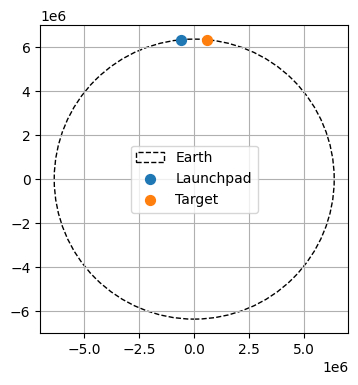

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1200
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")
waypoints = [launchpad, target]
plot_2D_planet_with_points(earth, points = waypoints, display="planet");

In [5]:
tomahawk, tomahawk_guidance

({'name': 'Tomahawk',
  'mass': 1300.0,
  'ref_radius': 0.25,
  'Cd': 0.5,
  'thrust_acc': 100.0,
  'max_range_m': 1600000},
 {'max_speed_m_s': 255.21750000000003,
  'altitude_settling_time_s': 60.0,
  'cruise_altitude_m': 50.0})

In [6]:
guidance_config = CruiseGuidanceConfig(waypoints=waypoints, **tomahawk_guidance)
guidance = CruiseWaypointGuidance(planet = earth, target=target, waypoints=waypoints)

tomahawk_missile = CruiseMissile(position=launchpad.position.copy(), config=CruiseMissileConfig(**tomahawk, guidance=guidance))
    

21:21:17 | INFO     | Guidance     | CruiseWaypointGuidance: spline built over 2 waypoints (8 dense points), total arc length 1200.0 km.


In [7]:
dt = 1.0
max_time = 5_000.0  # enough for 10 000 km at ~250 m/s

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[tomahawk_missile],
)

df = sim.results


21:21:18 | INFO     | Simulation   | Starting simulation.
21:21:20 | INFO     | Guidance     | Tomahawk reached terminal range (93 m from target).
21:21:20 | INFO     | Missile      | Tomahawk hit the ground.
21:21:20 | INFO     | Simulation   | Simulation ended at 3518.00s. Took 1.66 s of real time.


In [8]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

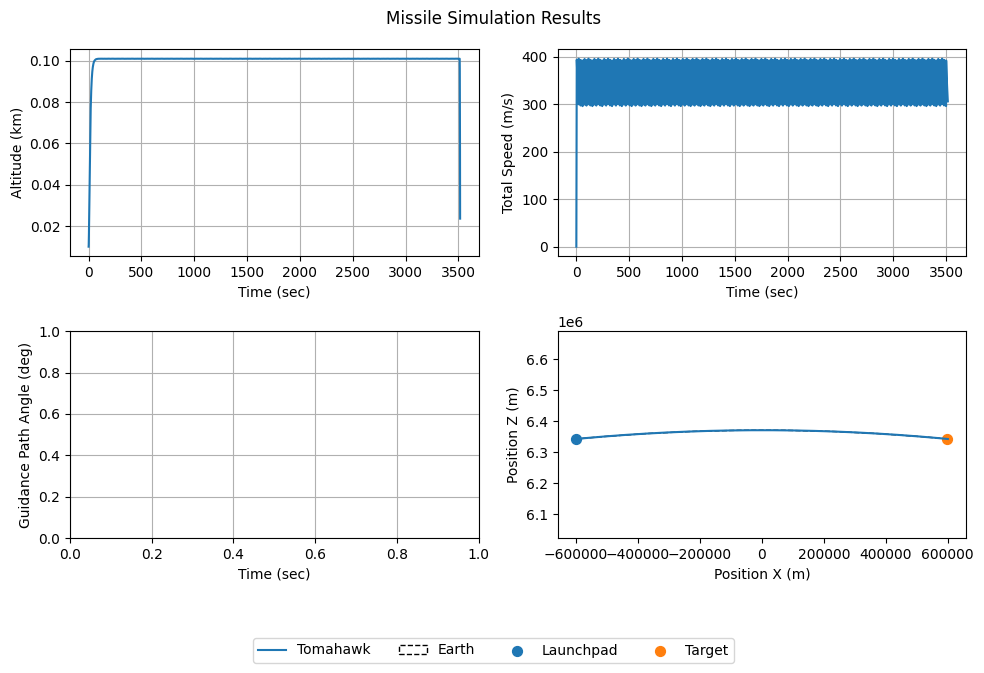

In [9]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)